In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import (
    WhiteKernel, ConstantKernel, RBF, RationalQuadratic, ExpSineSquared, DotProduct
)
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm
from src.feature_manager_sim import FeatureManagerSim
from src.feature_manager import FeatureManager
# import time
import time
# import metrics r_squared

In [15]:
# get the target, actual, and feature columns
feature_manager = FeatureManagerSim(features_config_path='../data/features_selected4.yaml')
feature_manager2 = FeatureManager(features_config_path='..//sto)
independent_variables = feature_manager2.get_features_for_time_pred(time_prediction='seven-day-ahead')
dependent_variables = feature_manager.get_dependent_variables(time_prediction='seven-day-ahead')
actuals_variables = feature_manager.get_actual_variables()

# print the outputs
print(f"Independent variables: {independent_variables}")
print(f"Dependent variables: {dependent_variables}")
print(f"Actual variables: {actuals_variables}")
# get the raw factor data
raw_ids = [x.split("_")[0] for x in independent_variables]
# check if the actuals and the raw_ids are in the data
# # load in the raw factor data
raw_data = pd.read_parquet('../data/fred_prorcessed_daily.parquet')
set(raw_ids + actuals_variables) - set(raw_data.columns.tolist())

INFO:src.feature_manager_sim:Loaded features for 6 future time predictions
INFO:src.feature_manager_sim:Available time predictions: ['one-day-ahead', 'thirty-day-ahead', 'future_values', 'seven-day-ahead', 'current_values', 'sixty-day-ahead']
INFO:src.feature_manager:Loaded features for 5 future time predictions
INFO:src.feature_manager:Available time predictions: ['one-day-ahead', 'thirty-day-ahead', 'seven-day-ahead', 'dependent_variables', 'sixty-day-ahead']
INFO:src.feature_manager:Retrieved 18 features for seven-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 dependent variables for seven-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 actual variables


Independent variables: ['U6RATE', 'MEDCPIM157SFRBCLE_moving_avg_60', 'STICKCPIM158SFRBATL_moving_avg_60', 'DGS5', 'DGS7', 'DGS10', 'DGS3', 'DGS3MO', 'DGS1', 'DGS30', 'REAINTRATREARAT1YE_moving_avg_60', 'DGS6MO', 'REAINTRATREARAT1YE_exp_moving_avg_60', 'MEDCPIM157SFRBCLE_exp_moving_avg_60', 'U6RATE_exp_moving_avg_60', 'DGS20', 'DGS1MO', 'DGS2']
Dependent variables: ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
Actual variables: ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']


set()

In [16]:
dependent_variable_new = []
for dep_var in actuals_variables:
        gain_loss_col = f'{dep_var}_future_val'
        dependent_variable_new.append(gain_loss_col)
        raw_data[gain_loss_col] = raw_data[dep_var].shift(-7)

# create the moving average for the raw ids
raw_data['MEDCPIM157SFRBCLE_moving_avg_60'] = raw_data['MEDCPIM157SFRBCLE'].rolling(window=60).mean()
raw_data['STICKCPIM158SFRBATL_moving_avg_60'] = raw_data['STICKCPIM158SFRBATL'].rolling(window=60).mean()
raw_data['REAINTRATREARAT1YE_moving_avg_60'] = raw_data['REAINTRATREARAT1YE'].rolling(window=60).mean()
raw_data['REAINTRATREARAT1YE_exp_moving_avg_60'] = raw_data['REAINTRATREARAT1YE'].ewm(span=60, adjust=False).mean()
raw_data['MEDCPIM157SFRBCLE_exp_moving_avg_60'] = raw_data['MEDCPIM157SFRBCLE'].ewm(span=60, adjust=False).mean()
raw_data['U6RATE_exp_moving_avg_60'] = raw_data['U6RATE'].ewm(span=60, adjust=False).mean()
# raw_data['REAINTRATREARAT1YE_exp_moving_avg_30'] = raw_data['REAINTRATREARAT1YE'].ewm(span=30, adjust=False).mean()

# ensure all the columns are available in the dataframe
full_columns = independent_variables + dependent_variables + actuals_variables + dependent_variable_new
set(full_columns) - set(raw_data.columns.tolist())

set()

In [17]:
# filer data
raw_data = raw_data[raw_data.index.to_timestamp() >= pd.to_datetime('2006-01-01')]
# raw_data.head()
# persist the full data
full_columns = set(independent_variables).union(set(dependent_variables)).union(set(actuals_variables).union(set(dependent_variable_new)))
raw_data[list(full_columns)].to_parquet('../data/kernel_regression_train_shifted_7_.parquet')

## Kernel Analysis

- Normalize the data
- Create a training, validation set, and a test set
- Analyze the relaitonship between our macro variables and index yields
- apply different kernels to the training set to identify regions where ecocomic activity may have an influence to yields

In [6]:
raw_data = pd.read_parquet('../data/kernel_regression_train_shifted_30_.parquet')
train_df = raw_data[(raw_data.index.to_timestamp() < pd.to_datetime('2018-01-01')) & (raw_data.index.to_timestamp() >= pd.to_datetime('2011-01-01'))]

analysis_df = train_df.iloc[:1500]
validation_df = train_df.iloc[1500:]
# get the min and max index values
print(f"Training Min index value: {analysis_df.index.min()}")
print(f"Training Max index value: {analysis_df.index.max()}")
print("\n")
print(f"Validation Min index value: {validation_df.index.min()}")
print(f"Validation Max index value: {validation_df.index.max()}")

Training Min index value: 2011-01-01
Training Max index value: 2015-02-08


Validation Min index value: 2015-02-09
Validation Max index value: 2017-12-31


In [7]:
scaler_y = StandardScaler()
scaler_x = StandardScaler()

analysis_df[independent_variables] = scaler_x.fit_transform(analysis_df[independent_variables])
analysis_df[dependent_variable_new] = scaler_y.fit_transform(analysis_df[dependent_variable_new])

transformed_cols = independent_variables + dependent_variable_new
analysis_df[transformed_cols].describe()

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_14827/2031720835.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df[independent_variables] = scaler_x.fit_transform(analysis_df[independent_variables])
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_14827/2031720835.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df[dependent_variable_new] = scaler_y.fit_transform(analysis_df[dependent_variable_new])


,U6RATE,MEDCPIM157SFRBCLE_moving_avg_60,STICKCPIM158SFRBATL_moving_avg_60,DGS5,DGS7,DGS10,DGS3,DGS3MO,DGS1,DGS30,...,DGS3MO_future_val,DGS6MO_future_val,DGS1_future_val,DGS2_future_val,DGS3_future_val,DGS5_future_val,DGS7_future_val,DGS10_future_val,DGS20_future_val,DGS30_future_val
count,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,...,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1500.000000,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03
mean,5.305386e-16,-8.337035e-16,3.789561e-17,3.221127e-16,-3.979039e-16,-5.021169e-16,-9.473903e-17,-1.894781e-16,-7.579123e-17,-7.579123e-17,...,7.579123e-17,-2.652693e-16,1.515825e-16,5.684342e-17,0.000000,4.168517e-16,1.515825e-16,-1.894781e-17,1.326346e-16,-1.004234e-15
std,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,...,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00
min,-2.056759e+00,-2.962346e+00,-3.214820e+00,-1.537072e+00,-1.688893e+00,-1.718607e+00,-1.309336e+00,-1.570287e+00,-1.483241e+00,-2.053729e+00,...,-1.594252e+00,-1.896610e+00,-1.515173e+00,-1.483241e+00,-1.307291,-1.549711e+00,-1.707926e+00,-1.731128e+00,-1.753808e+00,-2.045382e+00
25%,-8.744619e-01,-6.722049e-01,-5.863764e-01,-9.568505e-01,-8.823600e-01,-8.081181e-01,-9.185887e-01,-7.286612e-01,-8.739123e-01,-7.245370e-01,...,-9.962583e-01,-8.488557e-01,-8.865866e-01,-7.379394e-01,-0.917865,-9.577275e-01,-8.770661e-01,-7.874018e-01,-7.585717e-01,-7.332624e-01
50%,2.421519e-01,-1.127475e-01,-8.218632e-03,1.821037e-01,1.867656e-01,-1.206058e-01,-1.370932e-01,-1.675771e-01,-2.645839e-01,-2.602303e-01,...,-9.926703e-02,-3.249785e-01,-2.579999e-01,-3.314110e-01,-0.139013,2.043148e-01,1.856618e-01,-1.710906e-01,-2.431813e-01,-2.459037e-01
75%,7.019341e-01,5.744827e-01,5.710812e-01,8.053051e-01,7.307067e-01,6.783951e-01,8.575373e-01,6.740490e-01,5.478539e-01,5.727906e-01,...,7.977242e-01,9.847145e-01,5.801157e-01,4.816458e-01,0.852253,7.962987e-01,7.460092e-01,7.148569e-01,6.454228e-01,6.210325e-01
max,1.555815e+00,2.456175e+00,2.702662e+00,2.417033e+00,2.456313e+00,2.592281e+00,2.704708e+00,2.918385e+00,3.188277e+00,2.516506e+00,...,3.189701e+00,2.294407e+00,3.303991e+00,3.327345e+00,2.693176,2.484549e+00,2.562308e+00,2.737128e+00,2.724756e+00,2.659504e+00


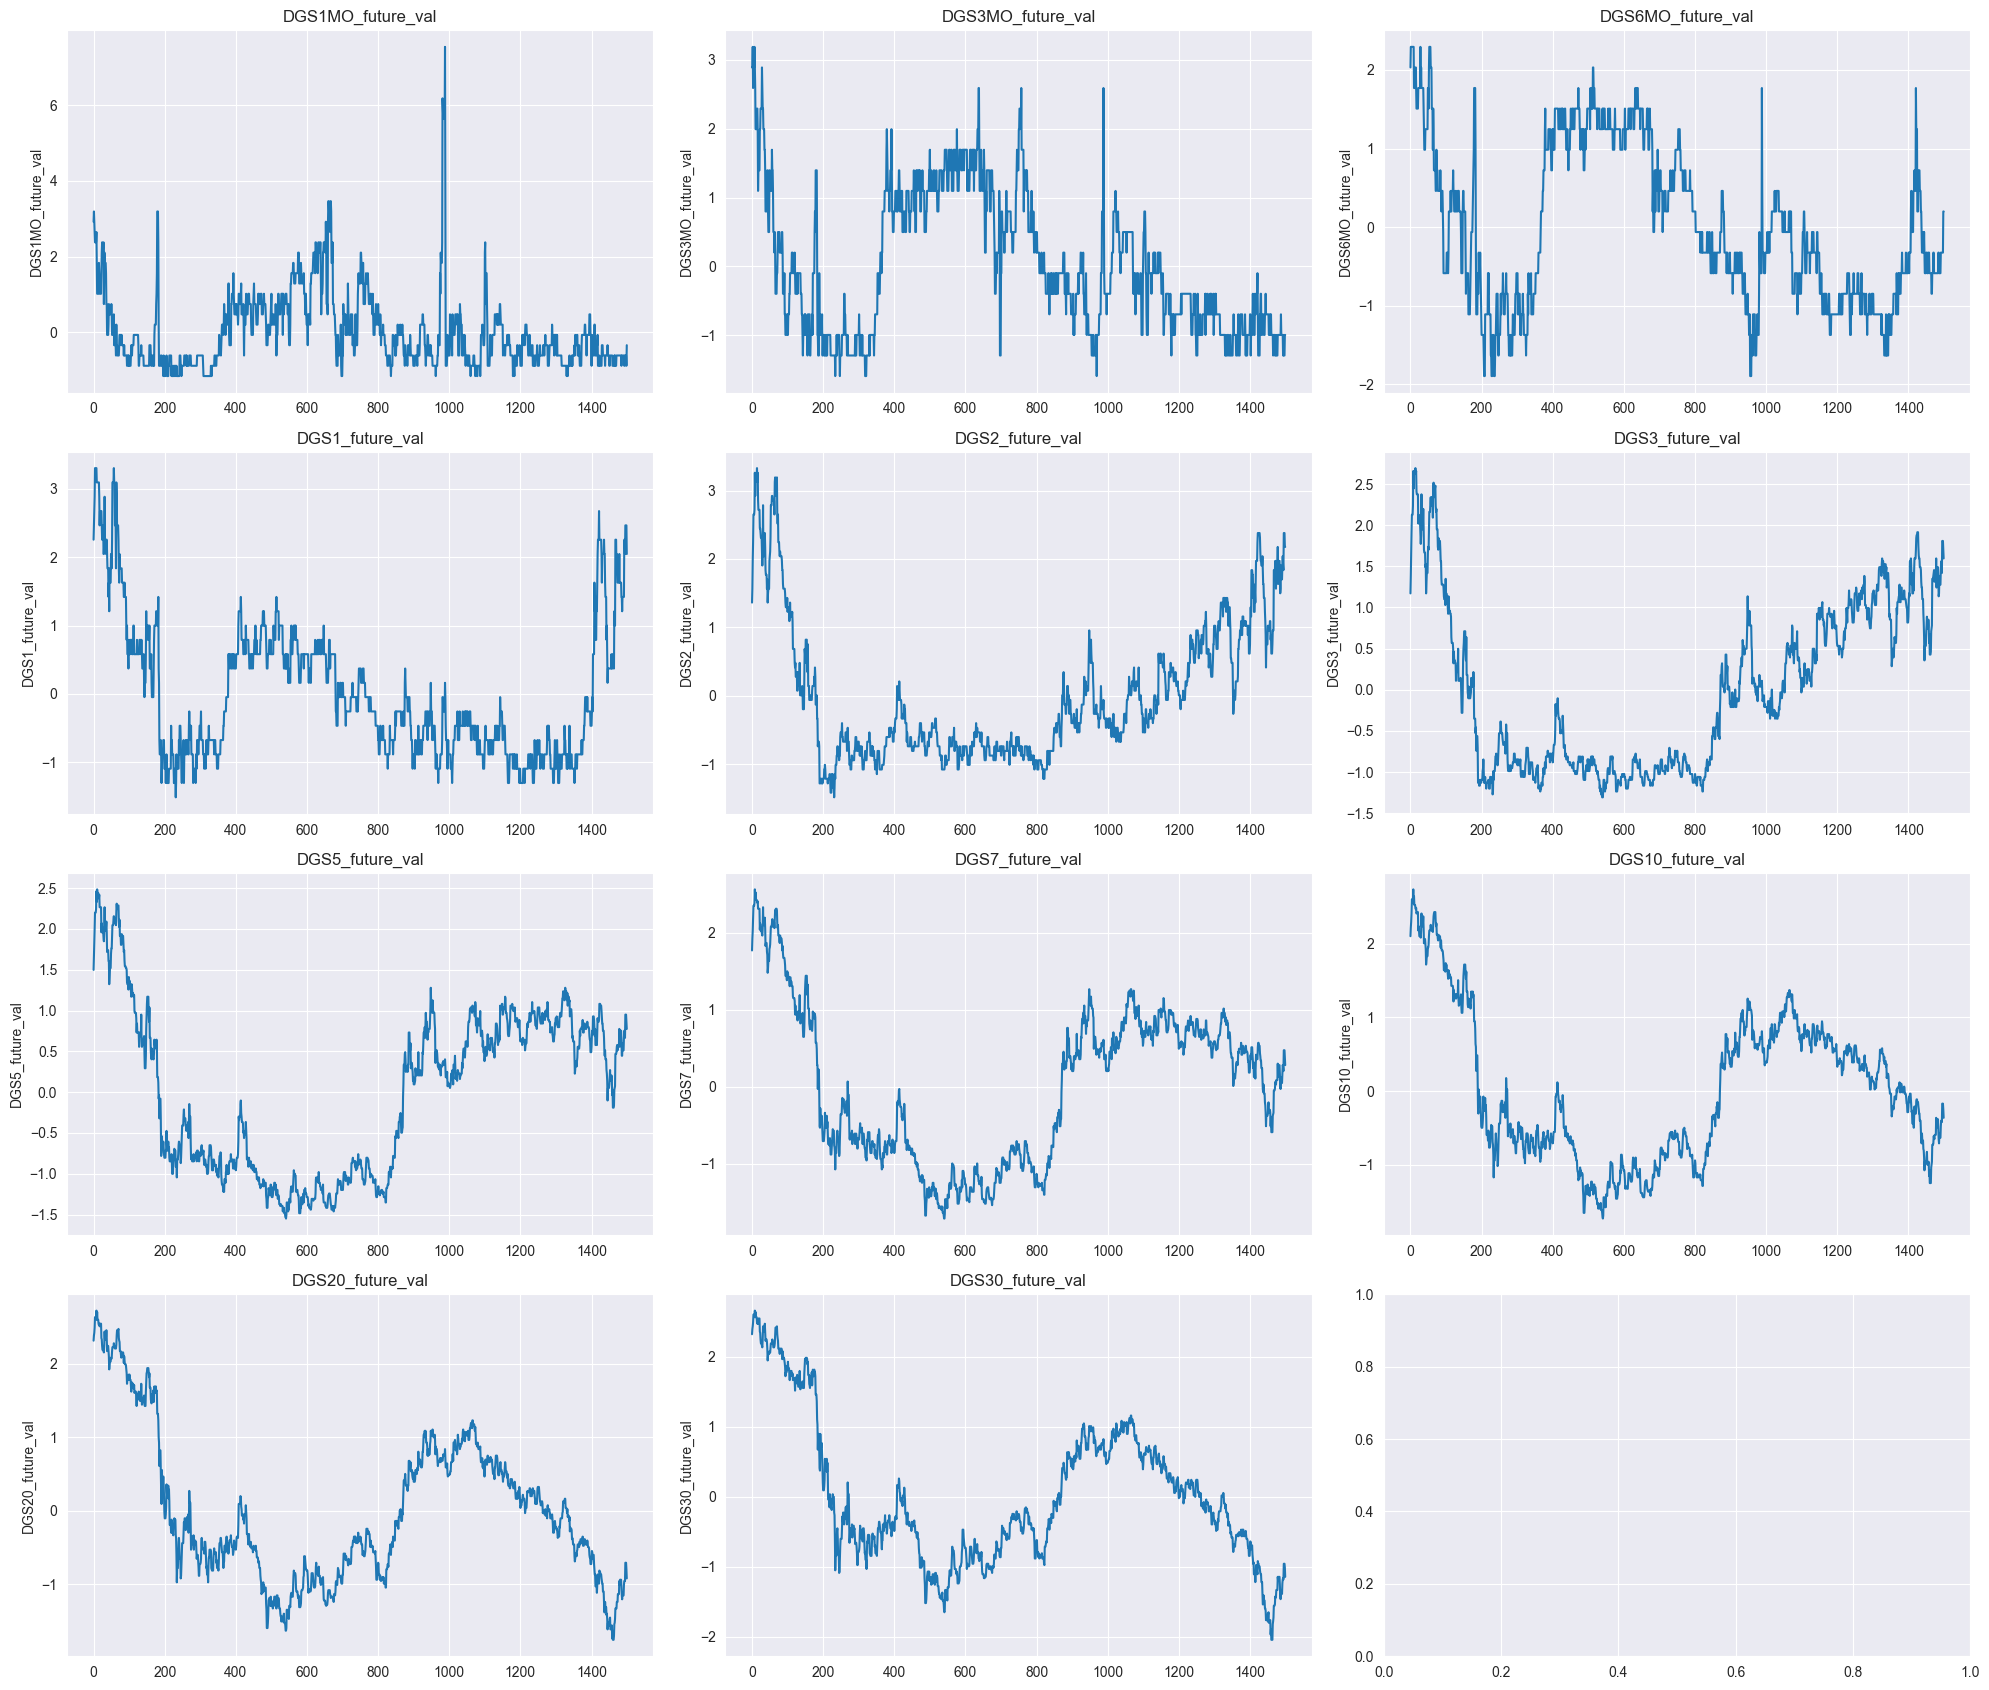

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(20, 17))
axes = axes.flatten()
xlables = [x for x in range(len(analysis_df))]
for i, dependent_var in enumerate(dependent_variable_new):
    sns.lineplot(analysis_df, x=xlables, y=dependent_var, ax=axes[i])
    axes[i].set_title(dependent_var)
plt.tight_layout()
plt.show()

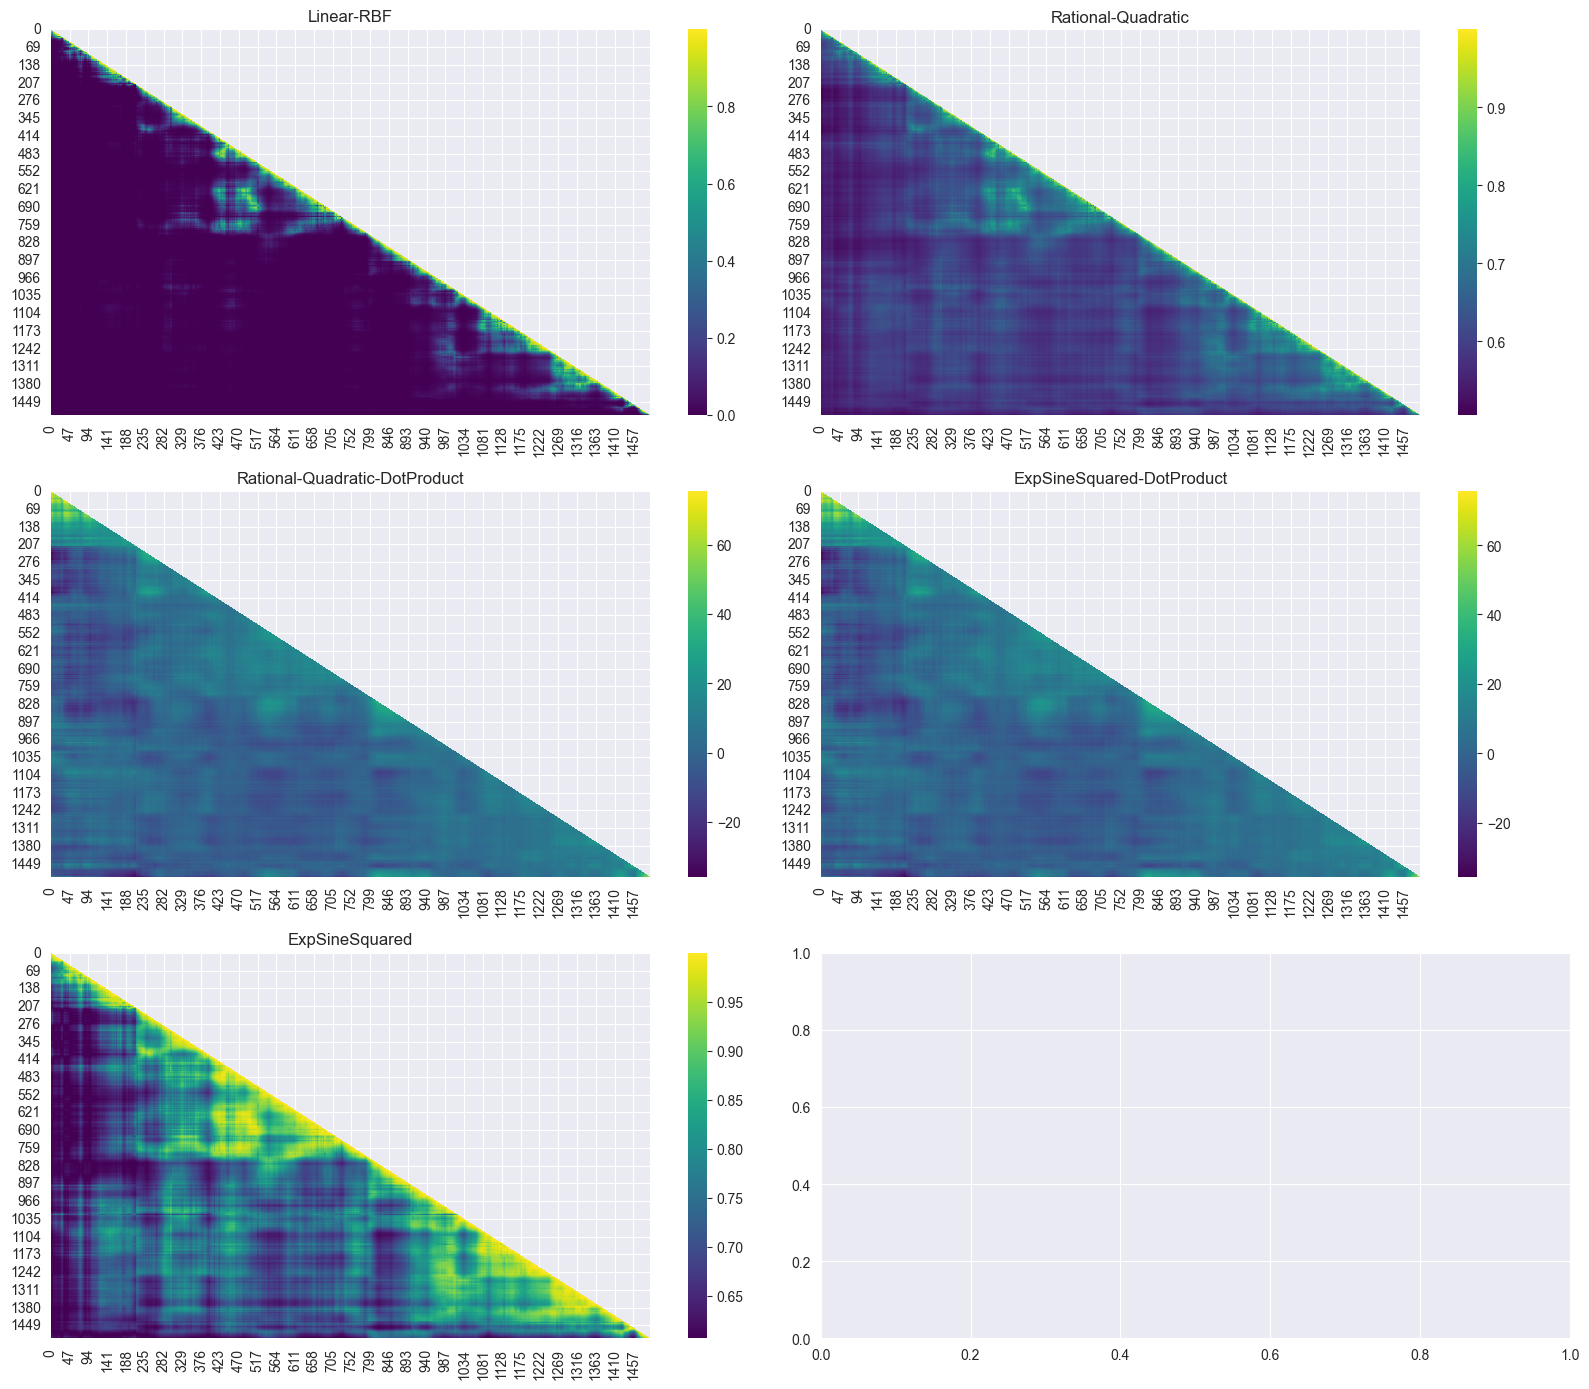

In [9]:
kernel_test = (ConstantKernel(1.0, (1e-3, 1e3)) *
                   # DotProduct() *
                   RBF(length_scale=1.5, length_scale_bounds=(1e-7, 1e7)) +
                   WhiteKernel(noise_level=1e-5))

kernel_test2 =(ConstantKernel(1.0, (1e-3, 1e3)) *
                                 # DotProduct() *
                                 RationalQuadratic(length_scale=1.0, alpha=0.1,
                                                 length_scale_bounds=(1e-5, 1e5),
                                                 alpha_bounds=(1e-5, 1e5)) +
                                 WhiteKernel(noise_level=1e-5))

kernel_test3 =(ConstantKernel(1.0, (1e-3, 1e3)) *
                                 DotProduct() +
                                 RationalQuadratic(length_scale=1.0, alpha=0.1,
                                                 length_scale_bounds=(1e-5, 1e5),
                                                 alpha_bounds=(1e-5, 1e5)) +
                                 WhiteKernel(noise_level=1e-5))

kernel_test4 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                              DotProduct() +
                              ExpSineSquared(length_scale=2, periodicity=20.0,
                                           length_scale_bounds=(0.01, 10),
                                           periodicity_bounds=(1e-2, 1e2)) +
                              WhiteKernel(noise_level=1e-5))

kernel_test5 = (ConstantKernel(1.0, (1e-3, 1e3)) *
                              # DotProduct() *
                              ExpSineSquared(length_scale=2, periodicity=20.0,
                                           length_scale_bounds=(0.01, 10),
                                           periodicity_bounds=(1e-2, 1e2)) +
                              WhiteKernel(noise_level=1e-5))

x_values = analysis_df[independent_variables].to_numpy()
xcov = kernel_test(x_values, x_values)
xcov2 = kernel_test2(x_values, x_values)
xcov3 = kernel_test3(x_values, x_values)
xcov4 = kernel_test4(x_values, x_values)
xcov5 = kernel_test5(x_values, x_values)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
cov_mats = [xcov, xcov2, xcov3, xcov4, xcov5]
titles = ["Linear-RBF", "Rational-Quadratic", "Rational-Quadratic-DotProduct", "ExpSineSquared-DotProduct", "ExpSineSquared"]
index_vals = [0, 1, 2, 3, 4]
for i, title, cov_mat in zip(index_vals, titles, cov_mats):
    sns.heatmap(cov_mat, cmap='viridis', mask=np.triu(np.ones_like(cov_mat, dtype=bool)), cbar=True, ax=axes[i])
    axes[i].set_title(f"{title}")
plt.tight_layout()
plt.show()

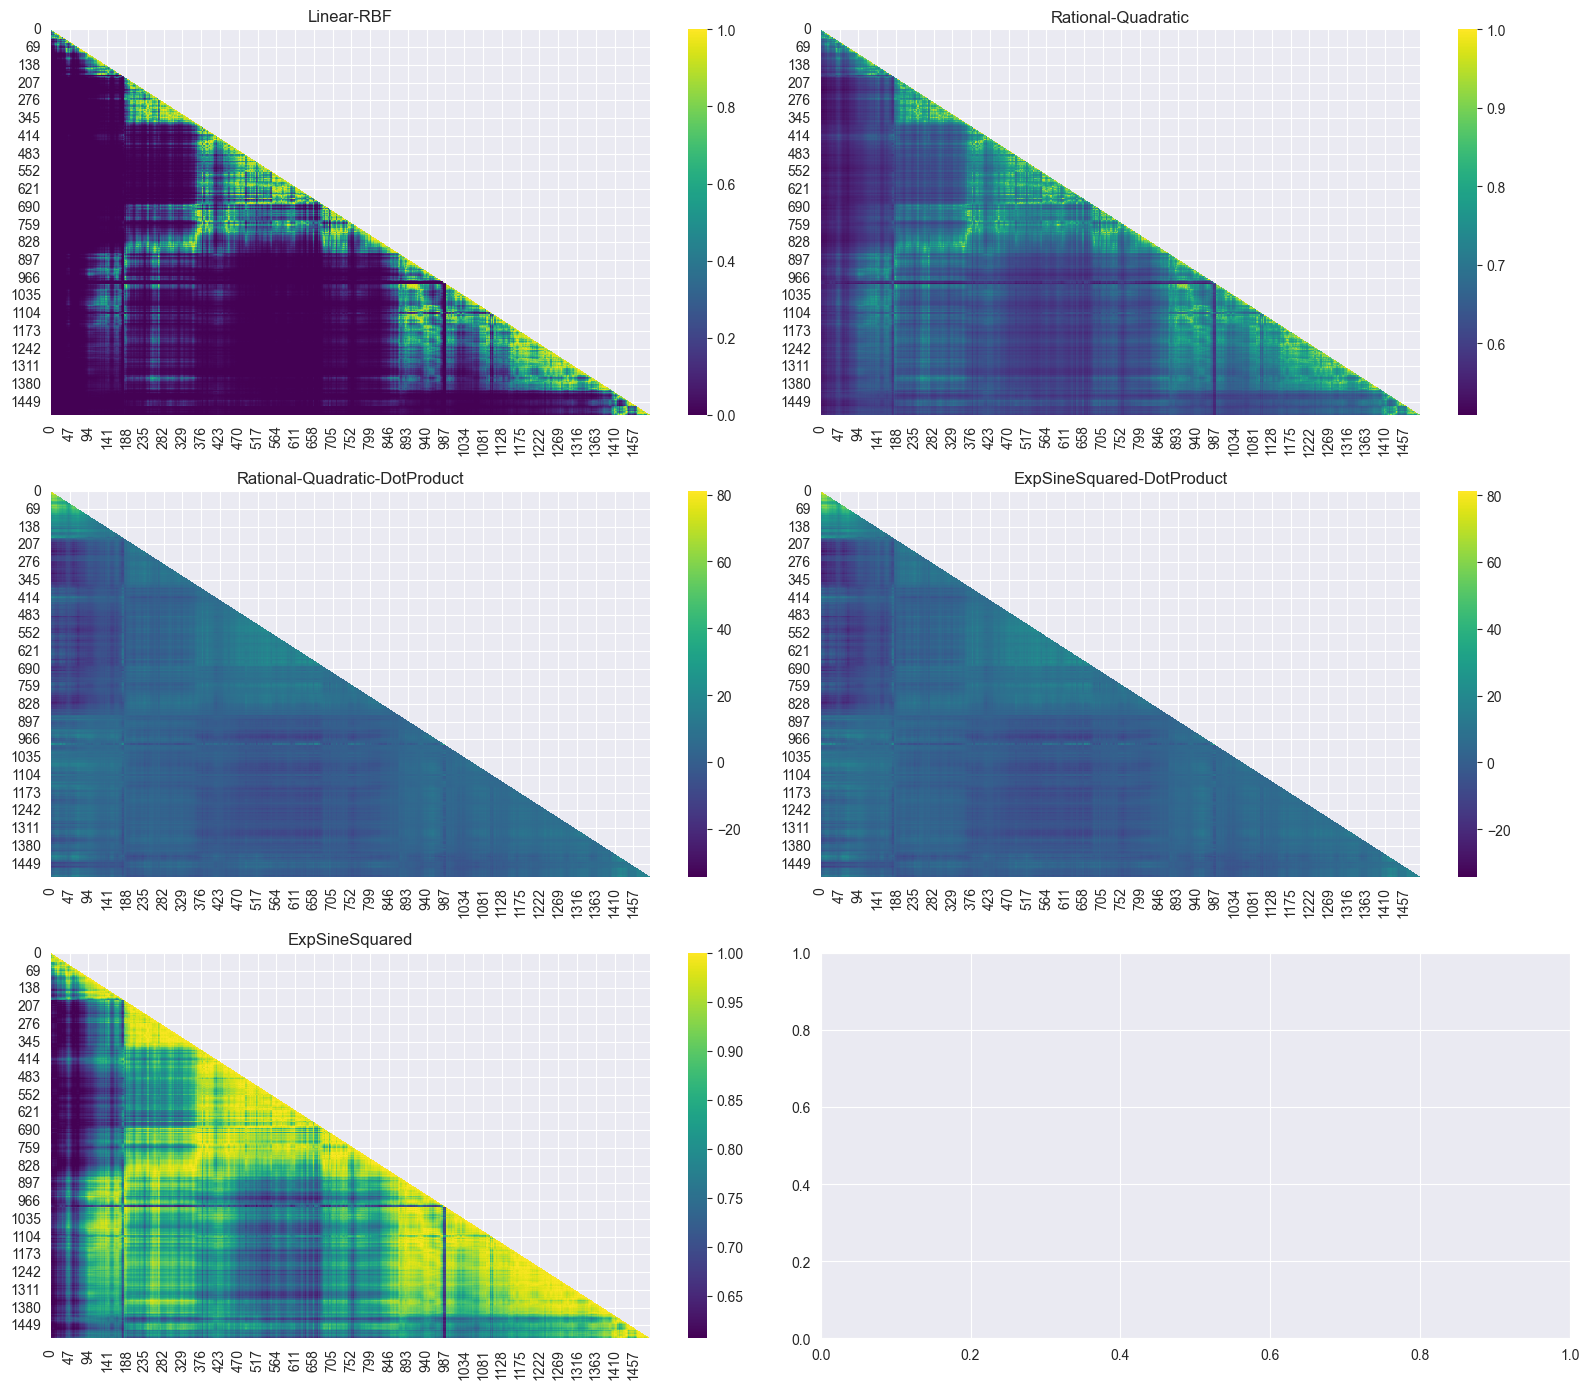

In [10]:
y_values = analysis_df[dependent_variable_new].to_numpy()
ycov = kernel_test(y_values, y_values)
ycov2 = kernel_test2(y_values, y_values)
ycov3 = kernel_test3(y_values, y_values)
ycov4 = kernel_test4(y_values, y_values)
ycov5 = kernel_test5(y_values, y_values)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
cov_mats = [ycov, ycov2, ycov3, ycov4, ycov5]
titles = ["Linear-RBF", "Rational-Quadratic", "Rational-Quadratic-DotProduct", "ExpSineSquared-DotProduct", "ExpSineSquared"]
index_vals = [0, 1, 2, 3, 4]
for i, title, cov_mat in zip(index_vals, titles, cov_mats):
    sns.heatmap(cov_mat, cmap='viridis', mask=np.triu(np.ones_like(cov_mat, dtype=bool)), cbar=True, ax=axes[i])
    axes[i].set_title(f"{title}")
plt.tight_layout()
plt.show()

## Gaussian Process Regression

- Train the model using the 4 test kernels
- Evaluate how well the model fit to the training data
- Use the models to predict the values of the validation set

In [ ]:
kernels = [
    kernel_test,
    kernel_test2,
    # kernel_test3,
    # kernel_test4,
    kernel_test5
]
models_list = []
for kernel in tqdm(kernels, desc="Training GPR Regression Models", total=len(kernels)):
    model = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=4, normalize_y=False)
    model = MultiOutputRegressor(model, n_jobs=2)
    model.fit(analysis_df[independent_variables], analysis_df[dependent_variable_new])
    models_list.append(model)

# get the training predictions
training_predictions = []
for model in tqdm(models_list, desc="Predicting Training Data", total=len(models_list)):
    training_prediction = model.predict(analysis_df[independent_variables])
    df_prediction = pd.DataFrame(training_prediction, columns=dependent_variable_new, index=analysis_df.index)
    df_prediction[dependent_variable_new] = scaler_y.inverse_transform(training_prediction)
    training_predictions.append(df_prediction)

# plot the training vs actuals
# inverse transform the dependent variable
actuals_columns = [f"{dep_var}_actual" for dep_var in dependent_variable_new]
predictions_actuals_list = []
for prediction in training_predictions:
    prediction[actuals_columns] = scaler_y.inverse_transform(analysis_df[dependent_variable_new])
    predictions_actuals_list.append(prediction)

predictions_actuals_list[0].head(5)

In [ ]:
predictions_actuals_list[0].describe()

In [ ]:
dgs_val = "DGS1MO_future_val"
# plot the predicted values together
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

titles = ["RBF", "Rational-Quadratic", "ExpSineSquared"]
index_vals = [0, 1, 2]

for i, title, prediction in zip(index_vals, titles, predictions_actuals_list):
    xlabels = [x for x in range(len(prediction))]
    sns.lineplot(prediction, x=xlables, y=dgs_val,  color='b', ax=axes[i])
    sns.lineplot(prediction, x=xlables, y=f"{dgs_val}_actual",  color='g', ax=axes[i])
    axes[i].set_title(f"{title}")
plt.tight_layout()
plt.show()

In [ ]:
# scale the validation set
validation_df[independent_variables] = scaler_x.transform(validation_df[independent_variables])
validation_df[dependent_variable_new] = scaler_y.transform(validation_df[dependent_variable_new])
# forecast on the validation set
validation_predictions = []
for model in tqdm(models_list, desc="Predicting Validation Data", total=len(models_list)):
    validation_prediction = model.predict(validation_df[independent_variables])
    df_prediction = pd.DataFrame(validation_prediction, columns=dependent_variable_new, index=validation_df.index)
    df_prediction[dependent_variable_new] = scaler_y.inverse_transform(validation_prediction)
    validation_predictions.append(df_prediction)

# add the actuals to the validation predictions
validation_predictions_actuals_list = []
for prediction in validation_predictions:
    prediction[actuals_columns] = scaler_y.inverse_transform(validation_df[dependent_variable_new])
    validation_predictions_actuals_list.append(prediction)

validation_predictions_actuals_list[0].describe()


In [ ]:
dgs_val = "DGS10_future_val"
# plot the predicted values together
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

titles = ["RBF", "Rational-Quadratic", "ExpSineSquared"]
index_vals = [0, 1, 2]

for i, title, val_prediction in zip(index_vals, titles, validation_predictions_actuals_list):
    xlabels = [x for x in range(len(val_prediction))]
    sns.lineplot(val_prediction, x=xlabels, y=dgs_val,  color='b', ax=axes[i])
    sns.lineplot(val_prediction, x=xlabels, y=f"{dgs_val}_actual",  color='g', ax=axes[i])
    axes[i].set_title(f"Validation of {title}")
plt.tight_layout()
plt.show()

In [ ]:
# test for stationarity in the validation set
records = []
for col in validation_predictions_actuals_list[0].columns.tolist():
    result = adfuller(validation_predictions_actuals_list[0][col])
    val = {
        'adf_statistic': result[0],
        'adf_pvalue': result[1],
        'column_name': col
    }
    records.append(val)

df_stationarity = pd.DataFrame(records)
# get the list of values that are not stationary
non_stationary_cols = df_stationarity[df_stationarity['adf_pvalue'] > 0.05]['column_name'].tolist()

print(f"Non-Stationary Columns: {len(non_stationary_cols)} / {len(df_stationarity)}")

In [ ]:
# get the residuals of the predictions
# residuals_list = []
# for val_prediction in validation_predictions_actuals_list:
#     for col in dependent_variable_new:
#         val_prediction[f"{col}_resids"] = val_prediction[f"{col}_actual"] - val_prediction[col]
#     residuals_list.append(val_prediction)

dgs_val = "DGS5_future_val"
# plot the residuals
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
head_val = None
for i, title, val_prediction in zip(index_vals, titles, residuals_list):
    if head_val is None:
        sns.scatterplot(val_prediction, x=dgs_val, y=f"{dgs_val}_resids",  color='y', ax=axes[i])
    else:
        sns.scatterplot(val_prediction.head(head_val), x=dgs_val, y=f"{dgs_val}_resids",  color='y', ax=axes[i])
    axes[i].set_title(f"Residuals of {title}")
    axes[i].set_xlabel("Predictions")
    axes[i].set_ylabel(f"Residuals")

plt.tight_layout()

In [ ]:
# get the distribution of a given point in the validation set and plot the distribution
time_period = '2015-12-09'
time_period_df = validation_df[validation_df.index.to_timestamp() == pd.to_datetime(time_period)]
index_list = validation_df.index.tolist()
# get the index values for the given time period
index_val = index_list.index(pd.Period(time_period))
print(f"Index value for {time_period}: {index_val}")

# samples_df = []
time_period_df[dependent_variable_new] = scaler_y.inverse_transform(time_period_df[dependent_variable_new])
for model in models_list:
    samples = {
        depend_var: list(estimator.sample_y(time_period_df[independent_variables], n_samples=1000)[0])
    for estimator, depend_var in zip(model.estimators_, dependent_variable_new)
    }
    samples = {
        key: [float(float_val) for float_val in val] for key, val in samples.items()
    }
    df_samples = pd.DataFrame(samples)
    df_samples[dependent_variable_new] = scaler_y.inverse_transform(df_samples)
    samples_df.append(df_samples)

# plot the distribtuoin of a predicted variable for each model
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
dgs_val = "DGS30_future_val"
for i, title, samples in zip(index_vals, titles, samples_df):
    sns.histplot(samples[dgs_val], kde=True, color='y', ax=axes[i])
    mean = samples[dgs_val].mean()
    # plot the mean value and the actual
    axes[i].axvline(mean, color='r', linestyle='--')
    axes[i].axvline(time_period_df[dgs_val].values[0], color='g', linestyle='--')
    axes[i].set_title(f"Distribution of {title}")
    axes[i].set_xlabel(f"{title}")
    axes[i].set_ylabel(f"Frequency")
plt.tight_layout()
plt.show()


## Kernel Regression

- fit a kernel regression model with the best parameters using timeseries cross_validation for each kernel
- evalutate the results on the validation set


In [ ]:
param_values = {
    'estimator__kernel': [kernel_test, kernel_test2, kernel_test5],
    'estimator__alpha': [1e-2, 1e0, 1e3, 1e4]
}
# formulate time series cross validation
multi_model = MultiOutputRegressor(KernelRidge())
cv = TimeSeriesSplit(n_splits=3, max_train_size=1000, test_size=100)
kernel_ridge_cv = GridSearchCV(multi_model, param_grid=param_values, cv=cv, n_jobs=3)

start_time = time.time()
kernel_riddg_best_model = kernel_ridge_cv.fit(analysis_df[independent_variables], analysis_df[dependent_variable_new])
print(f"Time for KernelRidge fitting: {time.time() - start_time:.3f} seconds")

In [ ]:
# get the predicted values
# kernel_riddg_best_model.cv_results_
kernel_riddg_best_model.best_estimator_.estimators_[0].kernel

In [ ]:
kernel_training_predictions = kernel_riddg_best_model.best_estimator_.predict(analysis_df[independent_variables])
df_prediction_kernel_ridge = pd.DataFrame(kernel_training_predictions, columns=dependent_variable_new, index=analysis_df.index)
df_prediction_kernel_ridge[dependent_variable_new] = scaler_y.inverse_transform(kernel_training_predictions)

# actuals
actuals_columns = [f"{dep_var}_actual" for dep_var in dependent_variable_new]
df_prediction_kernel_ridge[actuals_columns] = scaler_y.inverse_transform(analysis_df[dependent_variable_new])

# plot
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

for i, var in enumerate(dependent_variable_new):
    xlabels = [x for x in range(len(df_prediction_kernel_ridge))]
    sns.lineplot(df_prediction_kernel_ridge, x=xlabels, y=var,  color='b', ax=axes[i])
    sns.lineplot(df_prediction_kernel_ridge, x=xlabels, y=f"{var}_actual",  color='g', ax=axes[i])
    axes[i].set_title(f"Validation of {var}")
plt.tight_layout()
plt.show()

In [ ]:
# fit to the validation set
# scale the validation set
# validation_df[independent_variables] = scaler_x.transform(validation_df[independent_variables])
# validation_df[dependent_variable_new] = scaler_y.transform(validation_df[dependent_variable_new])
# forecast on the validation set
kernel_validation_predictions = kernel_riddg_best_model.best_estimator_.predict(validation_df[independent_variables])
df_val_prediction_kernel_ridge = pd.DataFrame(kernel_validation_predictions, columns=dependent_variable_new, index=validation_df.index)
df_val_prediction_kernel_ridge[dependent_variable_new] = scaler_y.inverse_transform(kernel_validation_predictions)


# add the actuals to the validation predictions
df_val_prediction_kernel_ridge[actuals_columns] = scaler_y.inverse_transform(validation_df[dependent_variable_new])

# plot
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

for i, var in enumerate(dependent_variable_new):
    xlabels = [x for x in range(len(df_val_prediction_kernel_ridge))]
    sns.lineplot(df_val_prediction_kernel_ridge, x=xlabels, y=var,  color='b', ax=axes[i])
    sns.lineplot(df_val_prediction_kernel_ridge, x=xlabels, y=f"{var}_actual",  color='g', ax=axes[i])
    axes[i].set_title(f"Validation of {var}")
plt.tight_layout()
plt.show()
